# Importing Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "svg"

In [2]:
#!pip install plotly

# Importing the Mumbai Zomato Dataset

In [3]:
raw_df = pd.read_csv("Zomato_Mumbai_Dataset.csv", delimiter = '|')

In [4]:
# Previewing first five records of the Mumbai Zomato Dataset

In [5]:
raw_df.head()

,NAME,PRICE,CUSINE_CATEGORY,CITY,REGION,URL,PAGE NO,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES
0,Hitchki,1200,"Modern Indian,North Indian,Chinese,Momos,Birya...",Mumbai,First International Financial Centre-- Bandra ...,https://www.zomato.com/mumbai/hitchki-bandra-k...,1,Casual Dining,12noon to 130am(Mon-Sun),Excellent,4.9,3529
1,Baba Falooda,400,"Desserts,Ice Cream,Beverages",Mumbai,Mahim,https://www.zomato.com/mumbai/baba-falooda-mah...,1,Dessert Parlor,2pm to 1am(Mon-Sun),Very Good,4.4,1723
2,Chin Chin Chu,1800,"Asian,Chinese",Mumbai,Juhu,https://www.zomato.com/mumbai/chin-chin-chu-ju...,1,Casual Dining,12noon to 1am(Mon-Sun),Very Good,4.2,337
3,Butterfly High,1000,Modern Indian,Mumbai,Bandra Kurla Complex,https://www.zomato.com/mumbai/butterfly-high-b...,1,Bar,12noon to 130am(Mon-Sun),Very Good,4.3,1200
4,BKC DIVE,1200,"North Indian,Chinese,Continental",Mumbai,Bandra Kurla Complex,https://www.zomato.com/mumbai/bkc-dive-bandra-...,1,Bar,1130am to 1am(Mon-Sun),Veľmi dobré,4.4,5995


# Getting Basic Information about the Dataset

In [6]:
raw_df.shape

(15081, 12)

In [7]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15081 entries, 0 to 15080
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   NAME             15081 non-null  object
 1   PRICE            15080 non-null  object
 2   CUSINE_CATEGORY  15079 non-null  object
 3   CITY             15080 non-null  object
 4   REGION           15080 non-null  object
 5   URL              15080 non-null  object
 6   PAGE NO          15080 non-null  object
 7   CUSINE TYPE      15080 non-null  object
 8   TIMING           15015 non-null  object
 9   RATING_TYPE      14070 non-null  object
 10  RATING           15080 non-null  object
 11  VOTES            15080 non-null  object
dtypes: object(12)
memory usage: 1.4+ MB


In [8]:
raw_df.describe()

,NAME,PRICE,CUSINE_CATEGORY,CITY,REGION,URL,PAGE NO,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES
count,15081,15080,15079,15080,15080,15080,15080,15080,15015,14070,15080,15080
unique,12720,67,3183,2,241,13823,944,23,2551,31,35,1124
top,NAME,400,CUSINE_CATEGORY,Mumbai,REGION,URL,PAGE NO,Quick Bites,11am to 11pm(Mon-Sun),Average,-,-
freq,942,2042,942,14138,942,942,942,5262,1192,5112,2360,2360


# Cleaning the Dataset

In [9]:
#Removing the Redundant data in the dataset

In [10]:
#wrong_name = raw_df["NAME"]=="NAME"
#raw_df[wrong_name]
#same results like PAGE NO

In [11]:
#wrong_price = raw_df["PRICE"]=="PRICE"
#raw_df[wrong_price]
#same results like PAGE NO

In [12]:
wrong_data = raw_df["PAGE NO"]=="PAGE NO"
raw_df[wrong_data]

,NAME,PRICE,CUSINE_CATEGORY,CITY,REGION,URL,PAGE NO,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES
15,NAME,PRICE,CUSINE_CATEGORY,CITY,REGION,URL,PAGE NO,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES
31,NAME,PRICE,CUSINE_CATEGORY,CITY,REGION,URL,PAGE NO,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES
47,NAME,PRICE,CUSINE_CATEGORY,CITY,REGION,URL,PAGE NO,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES
63,NAME,PRICE,CUSINE_CATEGORY,CITY,REGION,URL,PAGE NO,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES
79,NAME,PRICE,CUSINE_CATEGORY,CITY,REGION,URL,PAGE NO,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES
...,...,...,...,...,...,...,...,...,...,...,...,...
15000,NAME,PRICE,CUSINE_CATEGORY,CITY,REGION,URL,PAGE NO,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES
15016,NAME,PRICE,CUSINE_CATEGORY,CITY,REGION,URL,PAGE NO,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES
15032,NAME,PRICE,CUSINE_CATEGORY,CITY,REGION,URL,PAGE NO,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES
15048,NAME,PRICE,CUSINE_CATEGORY,CITY,REGION,URL,PAGE NO,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES


In [13]:
# All the above 942 rows have header names placed in cells, so need to remove them from the dataset

In [14]:
# Removing the redundant data shown above
raw_df = raw_df[~wrong_data]

In [15]:
# Dropping columns that are not required for data analysis
raw_df.drop(['CITY','URL', 'PAGE NO'], axis = 1, inplace = True)


In [16]:
raw_df.head()

,NAME,PRICE,CUSINE_CATEGORY,REGION,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES
0,Hitchki,1200,"Modern Indian,North Indian,Chinese,Momos,Birya...",First International Financial Centre-- Bandra ...,Casual Dining,12noon to 130am(Mon-Sun),Excellent,4.9,3529
1,Baba Falooda,400,"Desserts,Ice Cream,Beverages",Mahim,Dessert Parlor,2pm to 1am(Mon-Sun),Very Good,4.4,1723
2,Chin Chin Chu,1800,"Asian,Chinese",Juhu,Casual Dining,12noon to 1am(Mon-Sun),Very Good,4.2,337
3,Butterfly High,1000,Modern Indian,Bandra Kurla Complex,Bar,12noon to 130am(Mon-Sun),Very Good,4.3,1200
4,BKC DIVE,1200,"North Indian,Chinese,Continental",Bandra Kurla Complex,Bar,1130am to 1am(Mon-Sun),Veľmi dobré,4.4,5995


# Identify NULL Records and REMOVE them

In [17]:
#Checking NULL Records
raw_df.isnull().sum()

NAME                  0
PRICE                 1
CUSINE_CATEGORY       2
REGION                1
CUSINE TYPE           1
TIMING               66
RATING_TYPE        1011
RATING                1
VOTES                 1
dtype: int64

In [18]:
#Checking for a null row
raw_df[raw_df["PRICE"].isnull()]

,NAME,PRICE,CUSINE_CATEGORY,REGION,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES
15080,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
raw_df[raw_df["PRICE"].isnull()].isnull().all(axis=0)

NAME               False
PRICE               True
CUSINE_CATEGORY     True
REGION              True
CUSINE TYPE         True
TIMING              True
RATING_TYPE         True
RATING              True
VOTES               True
dtype: bool

In [20]:
#Dropping the above row from the dataset
raw_df = raw_df.drop(labels = 15080, axis=0)

In [21]:
#Checking for null values in other columns listed above
raw_df[raw_df["CUSINE_CATEGORY"].isnull()]

,NAME,PRICE,CUSINE_CATEGORY,REGION,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES
7338,Mother's Taste,400,NaN,Bhandup,none,11am to 11pm(Mon-Sun),Good,3.5,57


In [22]:
raw_df[raw_df["REGION"].isnull()]

,NAME,PRICE,CUSINE_CATEGORY,REGION,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES


In [23]:
raw_df[raw_df["REGION"].isnull()].isnull().all(axis=0)

NAME               True
PRICE              True
CUSINE_CATEGORY    True
REGION             True
CUSINE TYPE        True
TIMING             True
RATING_TYPE        True
RATING             True
VOTES              True
dtype: bool

In [24]:
raw_df[raw_df["CUSINE TYPE"].isnull()]

,NAME,PRICE,CUSINE_CATEGORY,REGION,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES


In [25]:
raw_df[raw_df["CUSINE TYPE"].isnull()].isnull().all(axis=0)

NAME               True
PRICE              True
CUSINE_CATEGORY    True
REGION             True
CUSINE TYPE        True
TIMING             True
RATING_TYPE        True
RATING             True
VOTES              True
dtype: bool

In [26]:
raw_df[raw_df["TIMING"].isnull()]

,NAME,PRICE,CUSINE_CATEGORY,REGION,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES
919,Uncle's Kitchen,300,Chinese,Malad West,Casual Dining,NaN,Good,3.7,1176
1045,Westside Bistro,500,"Italian,Mexican,Beverages,Pizza",Khopat-- Thane West,Casual Dining,NaN,Very Good,4.0,227
1569,Delta 9 Cafe,1000,"Continental,Chinese,North Indian,Beverages",Khopat-- Thane West,Casual Dining,NaN,NaN,NEW,NEW
2984,Burger Station,300,Fast Food,Near Andheri West Station,Quick Bites,NaN,NaN,Opening,Opening
3399,Bingo Burger,300,"Burger,Fast Food",Mira Road,Quick Bites,NaN,NaN,Opening,Opening
...,...,...,...,...,...,...,...,...,...
14472,Punjab Street,700,"North Indian,Chinese",Vashi,Quick Bites,NaN,Good,3.6,22
14914,MomoMaza,200,Chinese,Airoli,Casual Dining,NaN,Average,3.0,12
14972,Punjabi Tadka,300,North Indian,Jogeshwari,none,NaN,NaN,Opening,Opening
14987,New Good Luck Restaurant,0,"North Indian,Chinese,Fast Food,Beverages",Versova-- Andheri West,Quick Bites,NaN,NaN,Opening,Opening


In [27]:
raw_df[raw_df["RATING_TYPE"].isnull()]

,NAME,PRICE,CUSINE_CATEGORY,REGION,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES
34,Biryani 9,600,"Biryani,North Indian",Near Andheri East Station,none,11am to 3am(Mon-Sun),NaN,NEW,NEW
36,D Fusion Flavours,350,Chinese,Goregaon East,none,"12noon to 330pm,7pm to 3am(Mon-Sun)",NaN,NEW,NEW
84,Lajawab Kabab Corner,150,"Kebab,Fast Food",Sakinaka,Quick Bites,4pm to 1am(Mon-Sun),NaN,NEW,NEW
105,The Dark Kitchen,600,"Chinese,North Indian,Seafood",Manpada-- Thane West,none,12noon to 4am(Mon-Sun),NaN,NEW,NEW
106,Mokart,200,"Momos,Chinese,Fast Food",Khar,none,"1130am to 330pm,7pm to 1130pm...",NaN,NEW,NEW
...,...,...,...,...,...,...,...,...,...
14998,Foodies House,0,Chinese,Goregaon East,none,12noon to 4am(Mon-Sun),NaN,NEW,NEW
14999,Khansama,0,Biryani,Lower Parel,none,12noon to 3am(Mon-Sun),NaN,NEW,NEW
15010,Earth Cafe @ Waterfield,800,"Cafe,Healthy Food,Italian,Pizza,Beverages",Linking Road-- Bandra West,Café,"10am to 10pm(Mon-Thu),10am to 11pm(Fri-Sun)",NaN,NEW,NEW
15023,How About Some Cream,200,Beverages,Mumbai Central,Beverage Shop,12noon to 3am(Mon-Sun),NaN,NEW,NEW


In [28]:
raw_df[raw_df["VOTES"].isnull()]

,NAME,PRICE,CUSINE_CATEGORY,REGION,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES


In [29]:
raw_df[raw_df["VOTES"].isnull()].isnull().all(axis=0)

NAME               True
PRICE              True
CUSINE_CATEGORY    True
REGION             True
CUSINE TYPE        True
TIMING             True
RATING_TYPE        True
RATING             True
VOTES              True
dtype: bool

In [30]:
raw_df[raw_df["RATING"].isnull()]

,NAME,PRICE,CUSINE_CATEGORY,REGION,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES


In [31]:
raw_df[raw_df["RATING"].isnull()].isnull().all(axis=0)

NAME               True
PRICE              True
CUSINE_CATEGORY    True
REGION             True
CUSINE TYPE        True
TIMING             True
RATING_TYPE        True
RATING             True
VOTES              True
dtype: bool

# Replacing Null Records with NA

In [32]:
raw_df.fillna('NA', inplace=True)

In [33]:
#Confirming all the NULL records are replaced or removed
raw_df.isnull().sum()

NAME               0
PRICE              0
CUSINE_CATEGORY    0
REGION             0
CUSINE TYPE        0
TIMING             0
RATING_TYPE        0
RATING             0
VOTES              0
dtype: int64

# Converting the DataTypes of Numerical columns to Numeric DataType

In [34]:
#Numerical columns in the Dataset - PRICE, RATING and VOTES
#Checking each column values for any text or special characters and replace them with zero
raw_df["RATING"].value_counts()

RATING
-          2360
3.5        1094
3.4        1036
3.6         960
NEW         953
3.3         926
3.7         917
3.2         801
3.8         782
3.1         734
3.0         622
3.9         596
2.9         409
4.0         408
2.8         309
4.1         298
4.2         199
2.7         170
4.3         148
4.4          99
2.6          77
Opening      57
4.5          46
2.5          39
4.6          32
2.4          26
4.7          13
2.3          10
2.1           5
2.2           4
4.8           4
4.9           2
1.8           1
2.0           1
Name: count, dtype: int64

In [35]:
#Replacing the Text value to zero for the column "RATING"
raw_df["RATING"] = raw_df["RATING"].replace(to_replace=['-', 'NEW', 'Opening'], value = '0')

In [36]:
#Checking text values for the column VOTES and replacing them with zero
raw_df["VOTES"].value_counts()

VOTES
-       2360
NEW      953
4        364
5        320
6        288
        ... 
1029       1
7350       1
964        1
585        1
1249       1
Name: count, Length: 1123, dtype: int64

In [37]:
#Replacing the text value to zero for the column "VOTES"
raw_df["VOTES"] = raw_df["VOTES"].replace(to_replace = ['-', 'NEW', 'Opening'], value='0')

In [38]:
#Checking for text values in the column "PRICE"
raw_df["PRICE"].value_counts()

PRICE
400     2042
500     1954
300     1936
200     1177
600     1062
        ... 
5000       1
398        1
3500       1
1550       1
2700       1
Name: count, Length: 66, dtype: int64

In [39]:
#Changing the datatype to numeric data type for the columns - RATING, VOTES and PRICE
raw_df["PRICE"] = raw_df["PRICE"].astype('int64')
raw_df["RATING"] = raw_df["RATING"].astype('float64')
raw_df["VOTES"] = raw_df["VOTES"].astype('int64')

In [40]:
#Checking the datatype after conversion of datatype
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14138 entries, 0 to 15079
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   NAME             14138 non-null  object 
 1   PRICE            14138 non-null  int64  
 2   CUSINE_CATEGORY  14138 non-null  object 
 3   REGION           14138 non-null  object 
 4   CUSINE TYPE      14138 non-null  object 
 5   TIMING           14138 non-null  object 
 6   RATING_TYPE      14138 non-null  object 
 7   RATING           14138 non-null  float64
 8   VOTES            14138 non-null  int64  
dtypes: float64(1), int64(2), object(6)
memory usage: 1.1+ MB


In [41]:
#Checking the column "TIMIMG" for its values
raw_df["TIMING"].value_counts()

TIMING
11am to 11pm(Mon-Sun)                              1192
11am to 12midnight(Mon-Sun)                         632
12noon to 12midnight(Mon-Sun)                       467
11am to 1130pm(Mon-Sun)                             309
10am to 10pm(Mon-Sun)                               267
                                                   ... 
1130am to 4pm,630pm to 1230AM...                      1
12midnight to 5am,12noon to 12midnight(Mon-Sun)       1
12midnight to 1230AM,12noon to 4pm,7pm to ...         1
12noon to 330pm,630pm to 12midnight...                1
8am to 11pm,12midnight to 115am(Mon-Sun)              1
Name: count, Length: 2551, dtype: int64

In [42]:
#As both timing and days open are merged, splitting them into using string operation
temp_df = raw_df["TIMING"].str.split("(",n=1,expand=True)
temp_df

,0,1
0,12noon to 130am,Mon-Sun)
1,2pm to 1am,Mon-Sun)
2,12noon to 1am,Mon-Sun)
3,12noon to 130am,Mon-Sun)
4,1130am to 1am,Mon-Sun)
...,...,...
15075,"8am to 11pm,12midnight to 115am",Mon-Sun)
15076,11am to 230am,Mon-Sun)
15077,11am to 11pm,"Mon,Tue,Wed,Thu,Sun),11am to ..."
15078,9am to 1230AM,Mon-Sun)


In [43]:
raw_df["TIMING"] = temp_df[0]
raw_df["DAYS OPEN"] = temp_df[1]
raw_df.head()

,NAME,PRICE,CUSINE_CATEGORY,REGION,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES,DAYS OPEN
0,Hitchki,1200,"Modern Indian,North Indian,Chinese,Momos,Birya...",First International Financial Centre-- Bandra ...,Casual Dining,12noon to 130am,Excellent,4.9,3529,Mon-Sun)
1,Baba Falooda,400,"Desserts,Ice Cream,Beverages",Mahim,Dessert Parlor,2pm to 1am,Very Good,4.4,1723,Mon-Sun)
2,Chin Chin Chu,1800,"Asian,Chinese",Juhu,Casual Dining,12noon to 1am,Very Good,4.2,337,Mon-Sun)
3,Butterfly High,1000,Modern Indian,Bandra Kurla Complex,Bar,12noon to 130am,Very Good,4.3,1200,Mon-Sun)
4,BKC DIVE,1200,"North Indian,Chinese,Continental",Bandra Kurla Complex,Bar,1130am to 1am,Veľmi dobré,4.4,5995,Mon-Sun)


In [44]:
#DAYS OPEN column is shown above, the closing bracket can be removed
raw_df["DAYS OPEN"] = raw_df["DAYS OPEN"].str.replace(")","", regex=False)
raw_df.head()

,NAME,PRICE,CUSINE_CATEGORY,REGION,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES,DAYS OPEN
0,Hitchki,1200,"Modern Indian,North Indian,Chinese,Momos,Birya...",First International Financial Centre-- Bandra ...,Casual Dining,12noon to 130am,Excellent,4.9,3529,Mon-Sun
1,Baba Falooda,400,"Desserts,Ice Cream,Beverages",Mahim,Dessert Parlor,2pm to 1am,Very Good,4.4,1723,Mon-Sun
2,Chin Chin Chu,1800,"Asian,Chinese",Juhu,Casual Dining,12noon to 1am,Very Good,4.2,337,Mon-Sun
3,Butterfly High,1000,Modern Indian,Bandra Kurla Complex,Bar,12noon to 130am,Very Good,4.3,1200,Mon-Sun
4,BKC DIVE,1200,"North Indian,Chinese,Continental",Bandra Kurla Complex,Bar,1130am to 1am,Veľmi dobré,4.4,5995,Mon-Sun


In [45]:
#Checking for NULL values in the column "DAYS OPEN"
raw_df["DAYS OPEN"].isnull().sum()

160

In [46]:
#Replacing NULL values to NA in the column "DAYS OPEN"
raw_df["DAYS OPEN"] = raw_df["DAYS OPEN"].fillna('NA')

In [47]:
raw_df.info()
# null values are replaced in the column "DAYS OPEN"

<class 'pandas.core.frame.DataFrame'>
Index: 14138 entries, 0 to 15079
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   NAME             14138 non-null  object 
 1   PRICE            14138 non-null  int64  
 2   CUSINE_CATEGORY  14138 non-null  object 
 3   REGION           14138 non-null  object 
 4   CUSINE TYPE      14138 non-null  object 
 5   TIMING           14138 non-null  object 
 6   RATING_TYPE      14138 non-null  object 
 7   RATING           14138 non-null  float64
 8   VOTES            14138 non-null  int64  
 9   DAYS OPEN        14138 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 1.2+ MB


In [48]:
#Checking the values in the column "RATING TYPE"
raw_df["RATING_TYPE"].value_counts()

RATING_TYPE
Average          5112
Good             4330
Not rated        2360
Very Good        1137
NA               1010
Excellent          95
Poor               47
Veľmi dobré         6
Skvělá volba        4
Dobrze              4
Bardzo dobrze       3
İyi                 2
Dobré               2
Průměr              2
Ortalama            2
Promedio            2
Bueno               2
Priemer             2
Bom                 2
Buono               2
Muito Bom           2
Média               1
Baik                1
Skvělé              1
Biasa               1
Çok iyi             1
Sangat Baik         1
Excelente           1
Velmi dobré         1
Muy Bueno           1
Media               1
Name: count, dtype: int64

In [49]:
#Need to replace non-English words to unique Rating type in English
raw_df['RATING_TYPE'].replace(to_replace='Excelente', value = 'Excellent', inplace=True)
raw_df['RATING_TYPE'].replace(to_replace=['Veľmi dobré', 'Bardzo dobrze', 'Muy Bueno', 'Velmi dobré'], value='Very Good', inplace=True)
raw_df['RATING_TYPE'].replace(to_replace=['Skvělá volba', 'Dobrze', 'Bueno', 'Buono', 'Dobré', 'Bom', 'Skvělé'], value='Good', inplace=True)
raw_df['RATING_TYPE'].replace(to_replace=['Priemer', 'Média', 'Çok iyi'], value='Average', inplace=True)
raw_df['RATING_TYPE'].replace(to_replace=['Průměr', 'Promedio', 'Ortalama', 'Muito Bom', 'İyi'], value='Poor', inplace=True)
raw_df['RATING_TYPE'].replace(to_replace=['Baik', 'Biasa', 'Media', 'Sangat Baik'], value='Very Poor', inplace=True)

C:\Users\msshi\AppData\Local\Temp\ipykernel_3652\3644219160.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  raw_df['RATING_TYPE'].replace(to_replace='Excelente', value = 'Excellent', inplace=True)
C:\Users\msshi\AppData\Local\Temp\ipykernel_3652\3644219160.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting val

In [50]:
#Checking if the values correctly mapped
raw_df["RATING_TYPE"].value_counts()

RATING_TYPE
Average      5116
Good         4347
Not rated    2360
Very Good    1148
NA           1010
Excellent      96
Poor           57
Very Poor       4
Name: count, dtype: int64

In [51]:
#Checking the values of the column 'REGION'
raw_df["REGION"].value_counts()

REGION
Mira Road                               552
Malad West                              392
Chembur                                 349
Kharghar                                339
Vasai                                   331
                                       ... 
Sea Princess-- Juhu                       1
Juhu Residency Boutique Hotel-- Juhu      1
Royal Challenge Complex-- Goregaon        1
ITC Grand Central-- Parel                 1
Hotel Satkar Residency-- Majiwada         1
Name: count, Length: 240, dtype: int64

In [52]:
#Need to replace lengthy region data to a short meaningful data
raw_df["REGION"] = raw_df["REGION"].str.replace('[a-zA-Z].+-- ','', regex=True)
raw_df["REGION"] = raw_df["REGION"].str.replace('West|west|East|east', '', regex=True)                                                

In [53]:
raw_df["REGION"].value_counts()

REGION
Thane                934
Mira Road            559
Andheri              502
Malad                497
Kandivali            489
                    ... 
Trombay                2
CBD Belapur            1
Girgaon Chowpatty      1
Goregaon               1
Dadar                  1
Name: count, Length: 105, dtype: int64

# Find Duplicate Records and drop Duplicate records

In [54]:
raw_df[raw_df.duplicated()]

,NAME,PRICE,CUSINE_CATEGORY,REGION,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES,DAYS OPEN
3872,Star Garib Nawaz,400,North Indian,Mahakali,Quick Bites,6pm to 11pm,NA,0.0,0,Mon-Sun
4064,Sai Sannidhi Restaurant & Bar,1000,"North Indian,Konkan",Dahisar,Casual Dining,11am to 12midnight,Good,3.7,99,Mon-Sun
4068,Konkan Katta,400,"Seafood,Maharashtrian,Malwani",Mahakali,Quick Bites,"11am to 330pm,630pm to 1130pm",Good,3.5,181,Mon-Sun
4082,Usmaniya Hotel,600,Mughlai,Fort,Casual Dining,1030am to 1130pm,Average,3.2,8,Mon-Sun
4083,Gina's Cakes,450,Bakery,Dombivali,none,11am to 11pm,Good,3.5,49,Mon-Sun
...,...,...,...,...,...,...,...,...,...,...
14200,Mezbaan Family Restaurant,350,"Chinese,Mughlai",Mumbra,Dhaba,12noon to 1230AM,Average,2.8,97,Mon-Sun
14204,Jyoti Lunch Home,650,"Chinese,North Indian,Seafood,Mughlai",Mulund,Casual Dining,11am to 1230AM,Good,3.5,49,Mon-Sun
14253,On Toes,900,"Italian,North Indian,Chinese",Malad,Casual Dining,"12noon to 3pm,7pm to 1230AM",Good,3.6,76,Mon-Sun
14761,Frosty Farm,400,"Ice Cream,Desserts,Fast Food",Malad,Dessert Parlor,1pm to 1215AM,Good,3.6,120,Mon-Sun


In [55]:
raw_df.shape

(14138, 10)

In [56]:
raw_df = raw_df.drop_duplicates()

In [57]:
raw_df.shape
#Since duplicate records are deleted, the number of rows since drop have reduced

(13825, 10)

# Copying the cleaned data

In [58]:
zomato_df = raw_df.copy()
zomato_df.head()

,NAME,PRICE,CUSINE_CATEGORY,REGION,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES,DAYS OPEN
0,Hitchki,1200,"Modern Indian,North Indian,Chinese,Momos,Birya...",Bandra Kurla Complex,Casual Dining,12noon to 130am,Excellent,4.9,3529,Mon-Sun
1,Baba Falooda,400,"Desserts,Ice Cream,Beverages",Mahim,Dessert Parlor,2pm to 1am,Very Good,4.4,1723,Mon-Sun
2,Chin Chin Chu,1800,"Asian,Chinese",Juhu,Casual Dining,12noon to 1am,Very Good,4.2,337,Mon-Sun
3,Butterfly High,1000,Modern Indian,Bandra Kurla Complex,Bar,12noon to 130am,Very Good,4.3,1200,Mon-Sun
4,BKC DIVE,1200,"North Indian,Chinese,Continental",Bandra Kurla Complex,Bar,1130am to 1am,Very Good,4.4,5995,Mon-Sun


In [59]:
zomato_df.shape

(13825, 10)

In [60]:
zomato_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13825 entries, 0 to 15079
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   NAME             13825 non-null  object 
 1   PRICE            13825 non-null  int64  
 2   CUSINE_CATEGORY  13825 non-null  object 
 3   REGION           13825 non-null  object 
 4   CUSINE TYPE      13825 non-null  object 
 5   TIMING           13825 non-null  object 
 6   RATING_TYPE      13825 non-null  object 
 7   RATING           13825 non-null  float64
 8   VOTES            13825 non-null  int64  
 9   DAYS OPEN        13825 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 1.2+ MB


# Performing Exploratory Data Analysis

# Question1) How many restaurants are in Mumbai for each type of Cusine? - HISTOGRAM

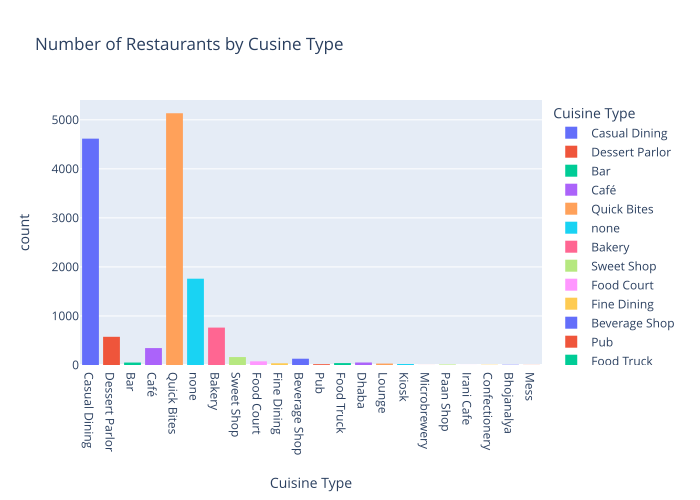

In [61]:
fig = px.histogram(zomato_df, x='CUSINE TYPE', color ='CUSINE TYPE', title = "Number of Restaurants by Cusine Type",
                   labels = {'CUSINE TYPE': 'Cuisine Type'})
fig.show()

In [62]:
#!pip install kaleido

# Question 2) What are the percentage of restaurants in Mumbai by Rating Type? - PIE CHART

In [63]:
#Percentage of restaurants is not available in the dataset, so we get the count of restaurants for each rating type and provide
#the dataset for pie chart creation
ratingtype_df = zomato_df["RATING_TYPE"].value_counts().reset_index()

In [64]:
ratingtype_df

,RATING_TYPE,count
0,Average,4984
1,Good,4263
2,Not rated,2297
3,Very Good,1145
4,NA,980
5,Excellent,96
6,Poor,56
7,Very Poor,4


In [65]:
#ratingtype_df = zomato_df["RATING_TYPE"].value_counts()

In [66]:
#ratingtype_df

In [67]:
#Renaming index above to RATING_TYPE and count to COUNT OF RESTAURANTS
ratingtype_df.rename(columns={'RATING_TYPE':'RATING TYPE', 'count':'Count of Restaurants'},inplace=True)

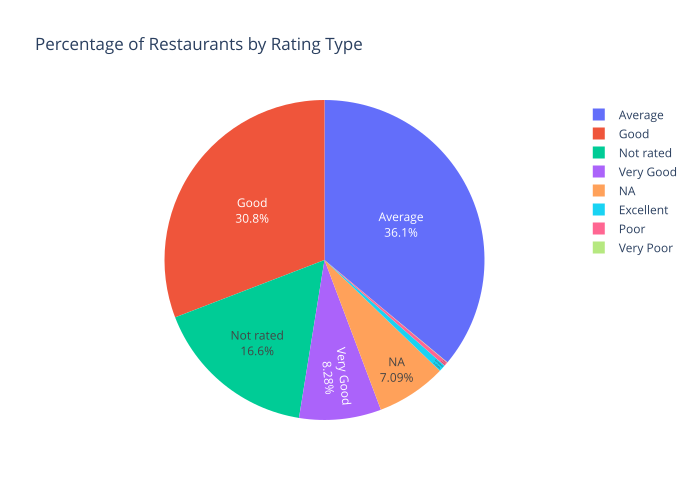

In [68]:
fig = px.pie(ratingtype_df, names = 'RATING TYPE', values = 'Count of Restaurants', color = 'RATING TYPE', 
             title = "Percentage of Restaurants by Rating Type").update_traces(textposition='inside', textinfo = 'percent+label')
fig.show()

# Question 3) Which are the top 10 highest rated Seafood Restaurant in Mumbai?

In [69]:
#All Seafood restaurants
seafood_df = zomato_df[zomato_df["CUSINE_CATEGORY"].str.contains("Seafood")]
seafood_df

,NAME,PRICE,CUSINE_CATEGORY,REGION,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES,DAYS OPEN
11,Raasta,1200,"Continental,Seafood,Fast Food,Desserts,Italian...",Khar,Casual Dining,12noon to 1am,Very Good,4.0,3191,Mon-Sun
18,Cafe Maaz,350,"Chinese,North Indian,Mughlai,Biryani,Seafood",Bhandup,Quick Bites,8am to 1230AM,Very Good,4.0,881,Mon-Sun
24,Kasbah Grand,1400,"North Indian,Mughlai,Chinese,Thai,Seafood",Goregaon,Casual Dining,12noon to 130am,Very Good,4.0,2280,"Mon-Fri,12noon to 3am(Sat-Sun"
76,Ceremonial Kitchen & Co,1000,"Seafood,Maharashtrian,North Indian,Chinese",Ghodbunder Road,Casual Dining,1130am to 1130pm,Excellent,4.6,350,Mon-Sun
85,Rajyog,800,"North Indian,Chinese,Seafood",Bandra,Casual Dining,1130am to 1230AM,Good,3.6,83,Mon-Sun
...,...,...,...,...,...,...,...,...,...,...
15025,Mahesh Lunch Home & Bar,550,"North Indian,Chinese,Seafood,Mughlai",Kurla,Casual Dining,1130am to 1230AM,Good,3.7,80,Mon-Sun
15026,Suyog Dinning Bar,600,"Chinese,North Indian,Seafood,Fast Food",Dahisar,Casual Dining,11am to 1am,Average,2.9,41,Mon-Sun
15031,Shark Bite,400,"Seafood,Rolls,BBQ",Mumbai Central,Quick Bites,6pm to 2am,Average,3.4,22,Mon-Sun
15045,Soul Fry,1000,"Goan,Seafood",Bandra,Casual Dining,"12noon to 3pm,7pm to 1am",Good,3.8,531,Mon-Sun


In [70]:
#Top 10 Highest rated Seafood Restaurants
seafood_df.sort_values(by='RATING', ascending = False).head(10)

,NAME,PRICE,CUSINE_CATEGORY,REGION,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES,DAYS OPEN
7104,Thangabali,1000,"Seafood,South Indian,Mangalorean,Andhra,Kerala",Khar,Bar,"12noon to 4pm,7pm to 3am",Excellent,4.7,564,Mon-Sun
13685,Maharashtra Lunch Home,600,"Maharashtrian,Malwani,Konkan,Seafood",Kharghar,Casual Dining,"11am to 345pm,7pm to 1145pm",Excellent,4.6,209,Mon-Sun
76,Ceremonial Kitchen & Co,1000,"Seafood,Maharashtrian,North Indian,Chinese",Ghodbunder Road,Casual Dining,1130am to 1130pm,Excellent,4.6,350,Mon-Sun
884,Rajmanya- Seafood family restaurant,800,"Maharashtrian,Konkan,Seafood",Vashi,Casual Dining,11am to 11pm,Excellent,4.5,178,Mon-Sun
902,The Harbour Bay - SeaFood Kitchen & Bar,2400,"Seafood,Beverages",Bandra,Casual Dining,12noon to 1am,Excellent,4.5,100,Mon-Sun
12433,Quarter Canteen,1100,"North Indian,Seafood,Chinese",Bandra,Casual Dining,"12noon to 330pm,7pm to 1am",Excellent,4.5,573,Mon-Sun
3380,Peco Peco,700,"Chinese,Seafood,Asian",Powai,none,"12noon to 330pm,7pm to 1230AM",Excellent,4.5,497,Mon-Sun
9954,Pi Bar and Kitchen,1600,"Continental,European,Italian,Seafood,Pizza,Des...",Andheri,Bar,"12noon to 6pm,7pm to 12midnight",Excellent,4.5,2068,Mon-Sun
199,Malhar Lunch Home,900,"North Indian,Seafood,Mughlai",Mira Road,Casual Dining,"1030am to 4pm,7pm to 1230AM",Very Good,4.4,1457,Mon-Sun
8890,Hardeep Punjab,1100,"North Indian,Chinese,Mughlai,Seafood",Sion,Casual Dining,11am to 1am,Very Good,4.4,871,Mon-Sun


# Question 4) Which is the best Food Truck in Mumbai?

In [71]:
foodtruck_df = zomato_df[zomato_df["CUSINE TYPE"]=="Food Truck"]
foodtruck_df
#Food Truck Restaurants

,NAME,PRICE,CUSINE_CATEGORY,REGION,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES,DAYS OPEN
262,Dumpling Delights,200,Momos,Matunga,Food Truck,430pm to 930pm,Very Good,4.3,212,Mon-Sun
1017,Street Food Co.,250,"Fast Food,Chinese",Virar,Food Truck,6pm to 3am,Very Good,4.1,274,Mon-Sun
1381,Veggies Treat,200,"Italian,Mexican,North Indian",Kandivali,Food Truck,7pm to 1130pm,Average,3.4,17,"Mon,7pm to 11pm(Tue,730pm to ..."
1689,Punjab Da Chullah- Bar Bank,500,"Fast Food,North Indian",Juhu,Food Truck,12noon to 1am,Average,3.4,26,Mon-Sun
2461,Bombay Food Truck,500,Fast Food,Bandra Kurla Complex,Food Truck,1130am to 730pm,Good,3.7,116,"Mon-Fri,Closed(Sat-Sun"
2667,Pizza Al Passeggio-Pizza On The Go,200,Fast Food,Tardeo,Food Truck,12noon to 12midnight,Good,3.5,17,"Mon-Sat,2pm to 12midnight..."
3639,Sobo Belly,400,"Mexican,Italian",Kandivali,Food Truck,5pm to 1130pm,Good,3.7,26,Mon-Sun
4386,Cheese On Fire,300,"Fast Food,Italian",Ghatkopar,Food Truck,530pm to 1130pm,Good,3.9,88,"Mon-Fri,530pm to 1230AM..."
5224,The Food Brigade,200,Chinese,Thane,Food Truck,,NA,0.0,0,"Mon,6am to 11pm(Tue-Sun"
5562,L' Dorado- Bar Bank,600,"American,Mexican",Juhu,Food Truck,12noon to 1am,Average,3.4,14,Mon-Sun


In [72]:
#Best Food Truck in Mumbai
foodtruck_df.sort_values(by="RATING", ascending=False).head(2)

,NAME,PRICE,CUSINE_CATEGORY,REGION,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES,DAYS OPEN
262,Dumpling Delights,200,Momos,Matunga,Food Truck,430pm to 930pm,Very Good,4.3,212,Mon-Sun
1017,Street Food Co.,250,"Fast Food,Chinese",Virar,Food Truck,6pm to 3am,Very Good,4.1,274,Mon-Sun


# Question 5) Which places have the highest rated restaurant for each cuisine type in Mumbai? HISTOGRAM

In [73]:
highestrated_df = zomato_df[zomato_df["RATING"]>=4.5]
highestrated_df    

,NAME,PRICE,CUSINE_CATEGORY,REGION,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES,DAYS OPEN
0,Hitchki,1200,"Modern Indian,North Indian,Chinese,Momos,Birya...",Bandra Kurla Complex,Casual Dining,12noon to 130am,Excellent,4.9,3529,Mon-Sun
6,Persian Darbar,1300,"Biryani,North Indian,Chinese,Mughlai",Marol,Casual Dining,10am to 3am,Excellent,4.5,3058,Mon-Sun
7,Tanatan,1500,Modern Indian,Juhu,Casual Dining,12noon to 130am,Excellent,4.7,1842,Mon-Sun
9,Plum by Bent Chair,1800,Asian,Kamala Mills Compound,Casual Dining,12noon to 1am,Excellent,4.7,1876,Mon-Sun
10,Angrezi Dhaba,1500,"North Indian,Chinese,Thai,European",Dadar,Bar,12noon to 1am,Excellent,4.5,2092,Mon-Sun
...,...,...,...,...,...,...,...,...,...,...
14228,Zaika Crave - Club Aquaria,1300,"North Indian,Continental,Chinese,Desserts",Borivali,Casual Dining,"11am to 330pm,7pm to 1130pm",Excellent,4.5,1302,"Mon,Tue,Wed..."
14234,Cone Culture,250,European,Kharghar,Casual Dining,Closed,Excellent,4.6,492,"Mon,12noon to 11pm(Tue-Sun"
15007,Dessertino,300,"Desserts,Ice Cream",Kandivali,Dessert Parlor,11am to 12midnight,Excellent,4.8,184,Mon-Sun
15051,Tick-eat,800,"North Indian,Italian,Chinese,Mexican,Lebanese",Mulund,Casual Dining,"1130am to 330pm,7pm to 1130pm",Excellent,4.5,754,Mon-Sun


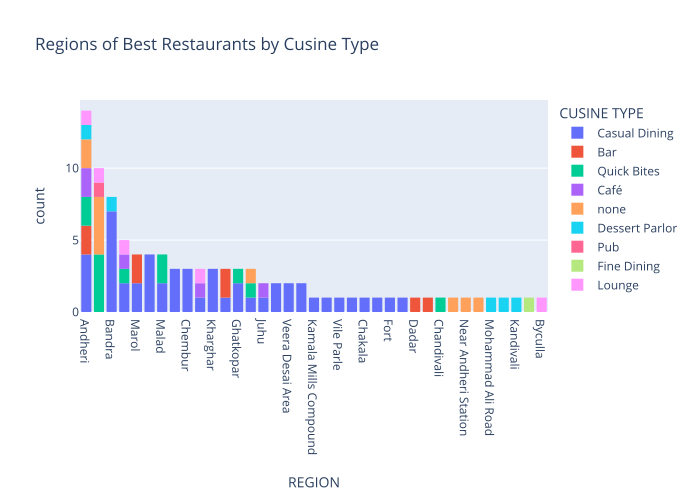

In [74]:
fig = px.histogram(highestrated_df, x="REGION", color = 'CUSINE TYPE', 
                   title = "Regions of Best Restaurants by Cusine Type").update_xaxes(categoryorder = "total descending")
fig.show()

# Q6) What is the Average Price distribution of highest rated restaurants for each cusine type in Mumbai? Bar Chart

In [75]:
highestratedprice_df = highestrated_df.groupby(by = ['RATING', 'CUSINE TYPE'])['PRICE'].mean().reset_index()
highestratedprice_df.head()

,RATING,CUSINE TYPE,PRICE
0,4.5,Bar,1540.000000
1,4.5,Café,900.000000
2,4.5,Casual Dining,1269.230769
3,4.5,Lounge,1650.000000
4,4.5,Pub,1400.000000


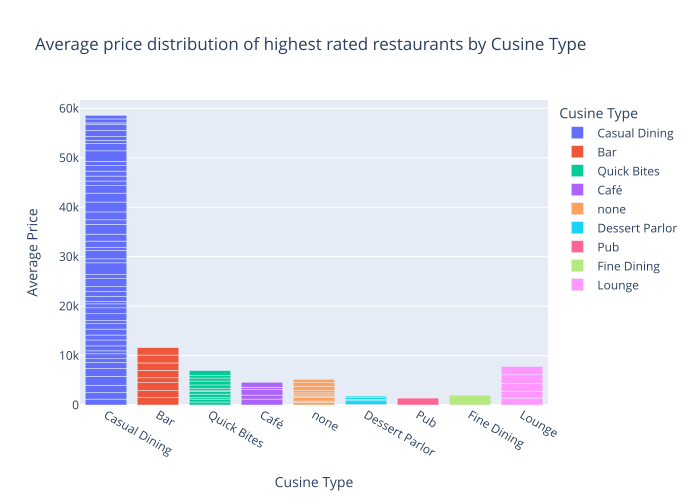

In [76]:
#Bar Chart
fig = px.bar(highestrated_df, x='CUSINE TYPE', y='PRICE', color='CUSINE TYPE', 
             title="Average price distribution of highest rated restaurants by Cusine Type", labels={"CUSINE TYPE":"Cusine Type",
                                                                                                     "PRICE":"Average Price"})
fig.show()

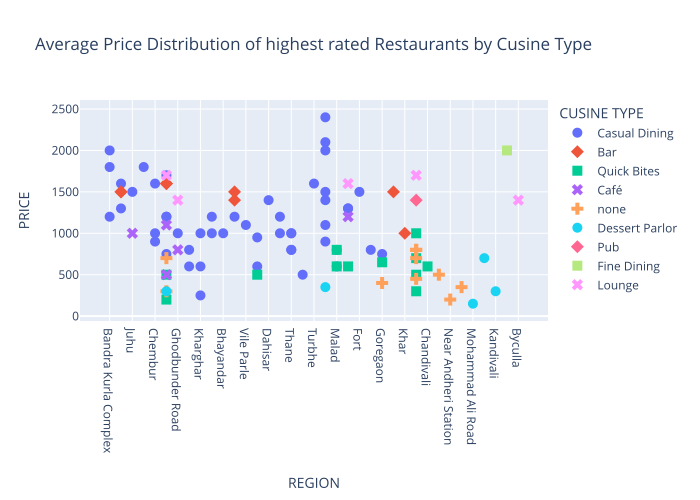

In [77]:
# Scatter Plot
fig = px.scatter(highestrated_df, x='REGION', y='PRICE', color = 'CUSINE TYPE', symbol = 'CUSINE TYPE',
                 title = "Average Price Distribution of highest rated Restaurants by Cusine Type").update_traces(marker_size=10)
fig.show()

# Question 7)Which areas have a large number of Chinese Restaurant Market?

In [78]:
chinese_df = zomato_df[zomato_df["CUSINE_CATEGORY"].str.contains("Chinese")]
chinese_df

,NAME,PRICE,CUSINE_CATEGORY,REGION,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES,DAYS OPEN
0,Hitchki,1200,"Modern Indian,North Indian,Chinese,Momos,Birya...",Bandra Kurla Complex,Casual Dining,12noon to 130am,Excellent,4.9,3529,Mon-Sun
2,Chin Chin Chu,1800,"Asian,Chinese",Juhu,Casual Dining,12noon to 1am,Very Good,4.2,337,Mon-Sun
4,BKC DIVE,1200,"North Indian,Chinese,Continental",Bandra Kurla Complex,Bar,1130am to 1am,Very Good,4.4,5995,Mon-Sun
5,Flea Bazaar Café,800,"American,Asian,Street Food,North Indian,Luckno...",Flea Bazaar Café,Café,12noon to 1am,Very Good,4.2,2042,Mon-Sun
6,Persian Darbar,1300,"Biryani,North Indian,Chinese,Mughlai",Marol,Casual Dining,10am to 3am,Excellent,4.5,3058,Mon-Sun
...,...,...,...,...,...,...,...,...,...,...
15071,Lucknow Zaika,500,"North Indian,Chinese",Kurla,Quick Bites,12noon to 2am,Average,2.6,36,Mon-Sun
15072,Zuha's Kitchen,400,"Chinese,North Indian,Mughlai",Mumbai Central,Quick Bites,"12noon to 4pm,730pm to 430am",Average,3.3,13,Mon-Sun
15075,Tirupati Balaji,500,"Chinese,Fast Food,North Indian",Andheri,Casual Dining,"8am to 11pm,12midnight to 115am",Good,3.5,267,Mon-Sun
15076,Hari Om Snack Bar,350,"Fast Food,South Indian,Chinese",Kandivali,Quick Bites,11am to 230am,Good,3.7,64,Mon-Sun


In [79]:
chinese_rest_df = chinese_df.groupby(by="REGION").agg({"NAME":"count", "PRICE": "mean"}).reset_index()


In [80]:
chinese_rest_df

,REGION,NAME,PRICE
0,4 Bungalows,38,593.421053
1,7 Andheri,29,606.896552
2,Airoli,92,501.086957
3,Alibaug,5,690.000000
4,Ambernath,22,575.000000
...,...,...,...
98,Vikhroli,49,510.204082
99,Vile Parle,61,596.721311
100,Virar,142,466.901408
101,Wadala,24,435.416667


In [81]:
chinese_rest_df.rename(columns = {"NAME": "Count of Restaurants"}, inplace = True)
chinese_rest_df

,REGION,Count of Restaurants,PRICE
0,4 Bungalows,38,593.421053
1,7 Andheri,29,606.896552
2,Airoli,92,501.086957
3,Alibaug,5,690.000000
4,Ambernath,22,575.000000
...,...,...,...
98,Vikhroli,49,510.204082
99,Vile Parle,61,596.721311
100,Virar,142,466.901408
101,Wadala,24,435.416667


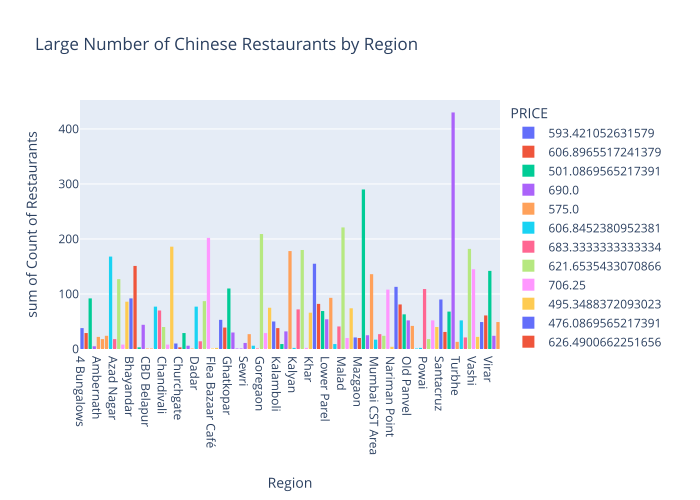

In [82]:
fig = px.histogram(chinese_rest_df, x="REGION", y = "Count of Restaurants", color = "PRICE", 
                   title = "Large Number of Chinese Restaurants by Region", labels = {"REGION": "Region"})
fig.show()

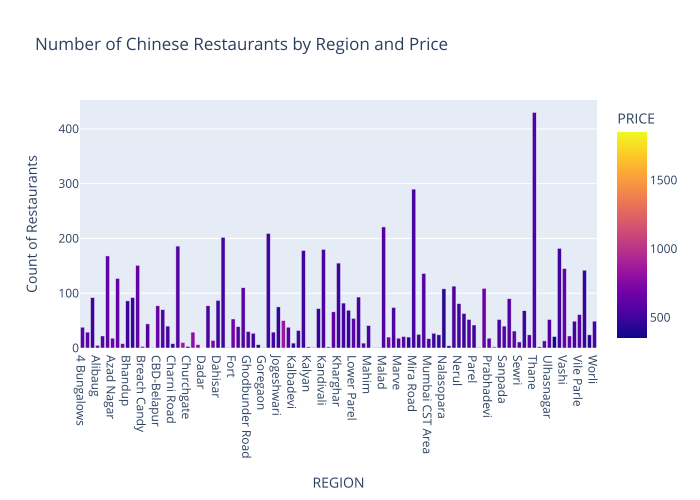

In [83]:
fig = px.bar(chinese_rest_df, x="REGION", y="Count of Restaurants", color = "PRICE",
             title = "Number of Chinese Restaurants by Region and Price")
fig.show()

# Question 8)Is there a relation between Price and Rating by each Cusine Type?

In [84]:
price_rating_df = zomato_df.groupby(["CUSINE TYPE", "RATING"])["PRICE"].mean().reset_index()
price_rating_df

,CUSINE TYPE,RATING,PRICE
0,Bakery,0.0,321.902655
1,Bakery,2.7,400.000000
2,Bakery,2.8,285.714286
3,Bakery,2.9,328.571429
4,Bakery,3.0,300.000000
...,...,...,...
296,none,4.3,683.333333
297,none,4.4,555.000000
298,none,4.5,420.000000
299,none,4.6,687.500000


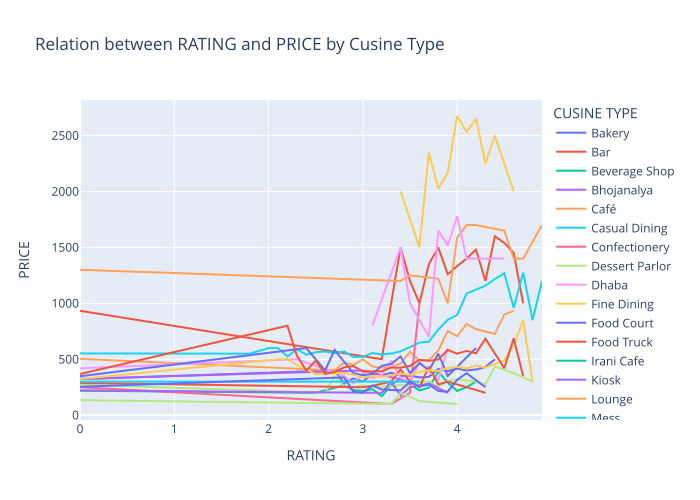

In [85]:
fig = px.line(price_rating_df, x="RATING", y="PRICE", color="CUSINE TYPE", title="Relation between RATING and PRICE by Cusine Type")
fig.show()

# Question 9)Is there a relation between Region and Price?

In [86]:
region_price_df = zomato_df.groupby(["REGION"])["PRICE"].mean().reset_index()
region_price_df

,REGION,PRICE
0,4 Bungalows,522.560976
1,7 Andheri,587.500000
2,Airoli,431.725888
3,Alibaug,647.222222
4,Ambernath,498.571429
...,...,...
100,Vikhroli,442.134831
101,Vile Parle,436.165049
102,Virar,418.400000
103,Wadala,391.964286


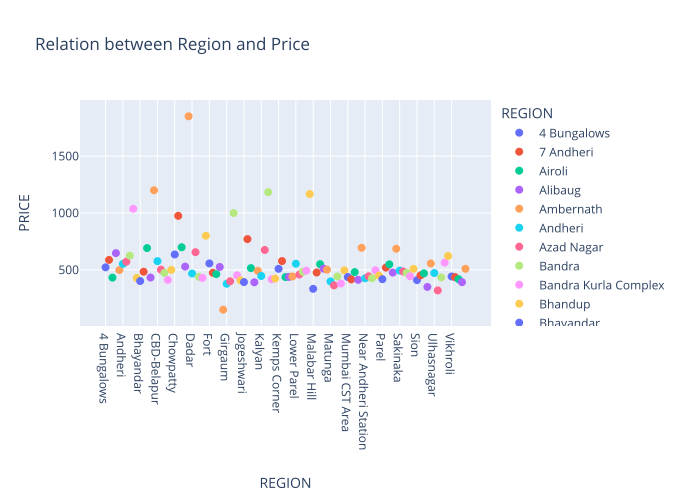

In [87]:
fig = px.scatter(region_price_df, x="REGION", y="PRICE", color = "REGION", title="Relation between Region and Price").update_traces(marker_size=8)
fig.show()

# Question 10) Find the list of affordable restaurants

In [88]:
#Low price, high rated - affordable restaurants
#low price - 1/4th of the mean price - df1
#high rated - rating>=4.5 - df2
#affordable restaurants - merge df1 and df2

In [89]:
#Low price - 1/4the price of maximum price
max_price = zomato_df["PRICE"].max()
one_fourth_price = max_price/4
one_fourth_price

1250.0

In [90]:
#low price restaurants
aff_rest_df = zomato_df[["NAME", "REGION", "PRICE", "CUSINE_CATEGORY", "CUSINE TYPE"]]
aff_rest_df = aff_rest_df[aff_rest_df["PRICE"]<=1250]
aff_rest_df.sort_values(by="PRICE", inplace=True)
aff_rest_df

,NAME,REGION,PRICE,CUSINE_CATEGORY,CUSINE TYPE
14987,New Good Luck Restaurant,Andheri,0,"North Indian,Chinese,Fast Food,Beverages",Quick Bites
14998,Foodies House,Goregaon,0,Chinese,none
14989,Patil Fast Food Centre,Charni Road,0,Fast Food,Quick Bites
14973,BKC - Thalis & Snacks,Thane,0,"North Indian,Fast Food",none
14971,Adler's Den,Andheri,0,Desserts,none
...,...,...,...,...,...
2850,The Mint Leaf Kitchen n Bar,Airoli,1200,"Chinese,North Indian,South Indian,Fast Food",Casual Dining
195,D:OH!,Andheri,1200,"Fast Food,Italian,Beverages",Casual Dining
6045,Fabelle at The Chocolate Boutique - ITC Grand ...,Parel,1250,Desserts,Dessert Parlor
7301,SamBar Pub & Kitchen,Khar,1250,"Finger Food,South Indian,North Indian",Pub


In [91]:
#high rated restaurants
high_rated_df = zomato_df[["NAME", "REGION", "PRICE", "CUSINE_CATEGORY", "CUSINE TYPE", "RATING"]]
high_rated_df = high_rated_df[high_rated_df["RATING"]>=4.5]
high_rated_df.sort_values(by="PRICE", inplace=True)
high_rated_df

,NAME,REGION,PRICE,CUSINE_CATEGORY,CUSINE TYPE,RATING
1502,Cake Centre-The Dessert Maker,Mohammad Ali Road,150,Desserts,Dessert Parlor,4.6
763,Curry And Combos Twist,Andheri,200,"North Indian,Chinese",Quick Bites,4.5
807,Moussestruck,Near Andheri Station,200,Desserts,none,4.5
14234,Cone Culture,Kharghar,250,European,Casual Dining,4.6
725,Belo Pops,Andheri,300,"Ice Cream,Desserts,Beverages",none,4.5
...,...,...,...,...,...,...
5335,Mia Cucina,Bandra,2000,Italian,Casual Dining,4.5
1786,Global Fusion,Worli,2000,"Chinese,Japanese,Asian,North Indian",Fine Dining,4.6
8887,Drifters Tap Station,Bandra Kurla Complex,2000,"North Indian,Continental,European,American",Casual Dining,4.5
12625,House of Mandarin,Bandra,2100,"Chinese,Sushi,Asian",Casual Dining,4.5


In [92]:
#Merging the two dfs for getting high rated and affordable restaurants
high_rated_aff_df = pd.merge(aff_rest_df, high_rated_df, how='inner', on = ["NAME", "REGION"])
high_rated_aff_df = high_rated_aff_df[["NAME", "REGION", "PRICE_x", "CUSINE_CATEGORY_x", "CUSINE TYPE_x"]]
high_rated_aff_df.rename(columns = {"NAME": "NAME", "REGION": "REGION", "PRICE_x":"PRICE", "CUSINE_CATEGORY_x": "CUSINE_CATEGORY", 
                                    "CUSINE_TYPE_x": "CUSINE TYPE"}, inplace=True)
high_rated_aff_df

,NAME,REGION,PRICE,CUSINE_CATEGORY,CUSINE TYPE_x
0,Cake Centre-The Dessert Maker,Mohammad Ali Road,150,Desserts,Dessert Parlor
1,Curry And Combos Twist,Andheri,200,"North Indian,Chinese",Quick Bites
2,Moussestruck,Near Andheri Station,200,Desserts,none
3,Cone Culture,Kharghar,250,European,Casual Dining
4,Smiley Pops,Andheri,300,"Desserts,Ice Cream,Beverages,Sandwich",Dessert Parlor
...,...,...,...,...,...
60,Angrezi Patiyalaa,Andheri,1200,"North Indian,Finger Food,American,Mexican,Chinese",Casual Dining
61,Invento,Lower Parel,1200,"Chinese,Fast Food,North Indian,Italian,Mexican",Casual Dining
62,Hitchki,Bandra Kurla Complex,1200,"Modern Indian,North Indian,Chinese,Momos,Birya...",Casual Dining
63,Culinary Tales,Veera Desai Area,1200,"Chinese,European,Continental,Salad,Italian,Pizza",Casual Dining


# Question 11) Find the list of most reliable restaurants

In [93]:
# Low price - high rated - large number of votes
# mean of votes - find restaurants - more than mean of votes - df
# merge highrated aff df with the above df

In [94]:
mean_votes = zomato_df["VOTES"].mean()

In [95]:
mean_votes

135.23479204339964

In [96]:
#Find restaurants having votes greater than mean of votes
mean_rest_df = zomato_df[["NAME", "REGION", "PRICE", "CUSINE_CATEGORY", "CUSINE TYPE", "RATING", "VOTES"]]
mean_rest_df = mean_rest_df[mean_rest_df["VOTES"]>135]
mean_rest_df.sort_values(by="VOTES", inplace=True)
mean_rest_df

,NAME,REGION,PRICE,CUSINE_CATEGORY,CUSINE TYPE,RATING,VOTES
10711,Simmering Pots,Bandra,600,"Mughlai,Biryani,North Indian,Kebab",none,3.9,136
3478,KBC - Kuch Bhi Chalega,Goregaon,500,"Fast Food,Healthy Food,Beverages,Desserts",Casual Dining,3.9,136
3485,Khichdi Samrat,Girgaum,350,North Indian,Casual Dining,2.8,136
1437,Tankstelle Bistro,Dombivali,700,"Chinese,Italian,Mexican,Continental",Pub,3.7,136
10678,Wowfillss,Kharghar,300,Desserts,Dessert Parlor,3.9,136
...,...,...,...,...,...,...,...
8539,Leopold Cafe & Bar,Colaba,1600,"American,Chinese,Mughlai,Italian",Casual Dining,3.9,7327
1251,Joey's Pizza,Malad,800,Pizza,Quick Bites,4.6,7350
5337,Chili's American Grill & Bar,Powai,1400,"American,Mexican,Burger,Tex-Mex",Casual Dining,4.3,7377
3751,Prithvi Cafe,Juhu,700,"Cafe,Fast Food",Café,4.4,8000


In [97]:
#Merge highrated aff df and mean rest df to get most reliable restaurants
reliable_rest_df = pd.merge(mean_rest_df, high_rated_aff_df, how='inner', on = ["NAME", "REGION"])
reliable_rest_df = reliable_rest_df[["NAME", "REGION", "PRICE_x", "CUSINE_CATEGORY_x", "CUSINE TYPE_x"]]
reliable_rest_df.rename(columns={"NAME": "NAME", "REGION": "REGION","PRICE_x": "PRICE", "CUSINE_CATEGORY_x": "CUSINE_CATEGORY",
                                 "CUSINE TYPE_x": "CUSINE TYPE"},inplace=True)
reliable_rest_df

,NAME,REGION,PRICE,CUSINE_CATEGORY,CUSINE TYPE
0,Sam's Bohri Zaika,Chandivali,600,"Bohri,North Indian,Mughlai,Kebab",Quick Bites
1,Too Much Drama,Vashi,600,"Fast Food,Roast Chicken,BBQ",Casual Dining
2,The Northern Vibe,Powai,300,"Momos,Rolls,Fast Food",Quick Bites
3,TBG- The Biryani Guys,Powai,450,"North Indian,Biryani",none
4,Downtown China,Andheri,750,"Chinese,Thai",Casual Dining
5,Cookstory,Andheri,700,"North Indian,Chinese,Mughlai",none
6,Rajmanya- Seafood family restaurant,Vashi,800,"Maharashtrian,Konkan,Seafood",Casual Dining
7,Fresh Food Co.,Santacruz,500,"Continental,Healthy Food,Salad,Beverages,Desse...",none
8,Dessertino,Kandivali,300,"Desserts,Ice Cream",Dessert Parlor
9,Invento,Lower Parel,1200,"Chinese,Fast Food,North Indian,Italian,Mexican",Casual Dining
